# Homework 07: Outliers, Risk, and Assumptions

This notebook reproducibly generates the assignment data, applies reusable IQR/Z-score/winsorizing methods, and measures how outlier treatment changes daily-return summary statistics.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Seeded setup and generated raw CSV

In [2]:
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name != 'homework07':
    candidate = PROJECT_DIR / 'homework' / 'homework07'
    if candidate.is_dir():
        PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

RANDOM_SEED = 5040
rng = np.random.default_rng(RANDOM_SEED)
dates = pd.bdate_range('2025-01-02', periods=240)
daily_return = rng.normal(loc=0.0004, scale=0.011, size=len(dates))
injected = {24: 0.092, 73: -0.108, 151: 0.075, 204: -0.082}
for position, value in injected.items():
    daily_return[position] = value

raw_df = pd.DataFrame({
    'date': dates,
    'daily_return': daily_return,
    'volume': rng.lognormal(mean=17.9, sigma=0.35, size=len(dates)).round().astype('int64'),
})
RAW_PATH = PROJECT_DIR / 'data' / 'raw' / 'stage07_returns.csv'
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
raw_df.to_csv(RAW_PATH, index=False)
print(f'Seed: {RANDOM_SEED}; saved {raw_df.shape} to {RAW_PATH.relative_to(PROJECT_DIR)}')
raw_df.head()

Seed: 5040; saved (240, 3) to data/raw/stage07_returns.csv


,date,daily_return,volume
0,2025-01-02,-0.015201,60072374
1,2025-01-03,0.004430,61790024
2,2025-01-06,-0.013546,112309924
3,2025-01-07,-0.009107,71058649
4,2025-01-08,-0.000348,115702092


## 2. Detect and flag outliers

In [3]:
analysis_df = pd.read_csv(RAW_PATH, parse_dates=['date'])
analysis_df['outlier_iqr'] = detect_outliers_iqr(analysis_df['daily_return'], k=1.5)
analysis_df['outlier_zscore'] = detect_outliers_zscore(analysis_df['daily_return'], threshold=3.0)
analysis_df['return_winsorized'] = winsorize_series(analysis_df['daily_return'], lower=0.05, upper=0.95)

method_counts = pd.Series({
    'IQR (k=1.5)': int(analysis_df['outlier_iqr'].sum()),
    'Z-score (threshold=3.0)': int(analysis_df['outlier_zscore'].sum()),
    'flagged_by_both': int((analysis_df['outlier_iqr'] & analysis_df['outlier_zscore']).sum()),
}, name='flagged_rows')
method_counts.to_frame()

,flagged_rows
IQR (k=1.5),6
Z-score (threshold=3.0),4
flagged_by_both,4


In [4]:
assert analysis_df[['outlier_iqr', 'outlier_zscore']].dtypes.eq(bool).all()
assert analysis_df['daily_return'].notna().all()
assert analysis_df.loc[list(injected), 'outlier_iqr'].all(), 'IQR failed to detect an injected extreme'
analysis_df.loc[analysis_df['outlier_iqr'] | analysis_df['outlier_zscore'], ['date', 'daily_return', 'outlier_iqr', 'outlier_zscore']]

,date,daily_return,outlier_iqr,outlier_zscore
24,2025-02-05,0.09200,True,True
73,2025-04-15,-0.10800,True,True
80,2025-04-24,-0.03089,True,False
151,2025-08-01,0.07500,True,True
204,2025-10-15,-0.08200,True,True
214,2025-10-29,-0.02819,True,False


## 3. Sensitivity analysis: all vs. filtered vs. winsorized

In [5]:
treatments = {
    'all_data': analysis_df['daily_return'],
    'iqr_filtered': analysis_df.loc[~analysis_df['outlier_iqr'], 'daily_return'],
    'winsorized_5_95': analysis_df['return_winsorized'],
}
summary = pd.DataFrame({
    name: {
        'n': series.count(),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'min': series.min(),
        'max': series.max(),
    }
    for name, series in treatments.items()
}).T
summary['std_change_vs_all_pct'] = (summary['std'] / summary.loc['all_data', 'std'] - 1) * 100
summary

,n,mean,median,std,min,max,std_change_vs_all_pct
all_data,240.0,0.001632,0.001568,0.016103,-0.108000,0.092000,0.000000
iqr_filtered,234.0,0.002024,0.001710,0.010850,-0.025836,0.030649,-32.619999
winsorized_5_95,240.0,0.001859,0.001568,0.010495,-0.016807,0.019998,-34.826918


In [6]:
assert summary.loc['iqr_filtered', 'n'] < summary.loc['all_data', 'n']
assert summary.loc['iqr_filtered', 'std'] < summary.loc['all_data', 'std']
assert summary.loc['winsorized_5_95', 'std'] < summary.loc['all_data', 'std']
print(f"IQR filtering changes standard deviation by {summary.loc['iqr_filtered', 'std_change_vs_all_pct']:.1f}%.")
print(f"Winsorizing changes standard deviation by {summary.loc['winsorized_5_95', 'std_change_vs_all_pct']:.1f}%.")

IQR filtering changes standard deviation by -32.6%.
Winsorizing changes standard deviation by -34.8%.


## 4. Visual comparison

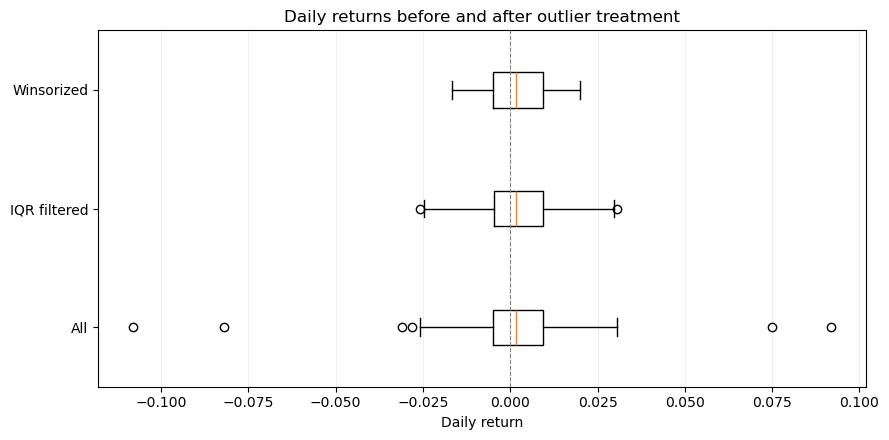

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.boxplot([treatments[name].dropna() for name in treatments], tick_labels=['All', 'IQR filtered', 'Winsorized'], vert=False)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set(title='Daily returns before and after outlier treatment', xlabel='Daily return')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

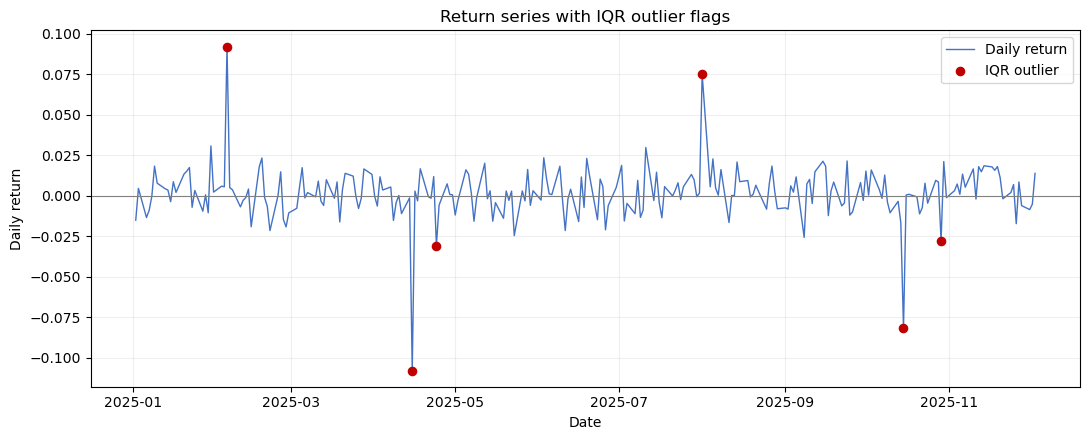

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(analysis_df['date'], analysis_df['daily_return'], color='#4472C4', linewidth=1, label='Daily return')
flagged = analysis_df[analysis_df['outlier_iqr']]
ax.scatter(flagged['date'], flagged['daily_return'], color='#C00000', s=35, zorder=3, label='IQR outlier')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set(title='Return series with IQR outlier flags', xlabel='Date', ylabel='Daily return')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Reflection: assumptions and risks

I used the IQR rule with `k=1.5` as the primary flag because it does not assume normality and daily financial returns often have heavy tails. I also used an absolute Z-score threshold of 3.0 as a comparison. Z-scores are easy to interpret under an approximately stable, symmetric distribution, but the mean and standard deviation used by the method are themselves influenced by extreme observations. The two methods' flag counts above show whether that modeling assumption changes the conclusion on this sample.

The sensitivity table compares three defensible treatments. The all-data case preserves every observed shock. IQR filtering removes flagged rows and therefore estimates typical-day variation, but it can understate real tail risk. Winsorizing at the 5th and 95th percentiles retains the full sample size while limiting influence; however, it replaces genuine extremes and compresses dispersion. Median moves less than mean because it is resistant to extremes, while the change in standard deviation quantifies how strongly tail observations drive estimated risk.

This analysis assumes observations are comparable through time, the seeded synthetic shocks are representative of the outlier problem, and a univariate rule is adequate. If returns undergo a volatility regime shift, clustered large moves may be valid rather than erroneous. If those assumptions are wrong, filtering or winsorizing could erase the most decision-relevant risk. For market-risk reporting I would keep the raw series, label rather than silently delete observations, report all three treatments, and investigate flagged dates using domain evidence before choosing a production rule.